In [ ]:
pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 42.3 MB/s eta 0:00:00


Step 0001 | Train loss 0.7555 acc 0.616 | Test loss 0.7564 acc 0.573
Step 0005 | Train loss 0.6960 acc 0.733 | Test loss 0.6966 acc 0.720
Step 0010 | Train loss 0.6201 acc 0.793 | Test loss 0.6226 acc 0.760
Step 0015 | Train loss 0.5718 acc 0.789 | Test loss 0.5731 acc 0.793
Step 0020 | Train loss 0.5497 acc 0.773 | Test loss 0.5520 acc 0.780
Step 0025 | Train loss 0.5380 acc 0.776 | Test loss 0.5428 acc 0.800
Step 0030 | Train loss 0.5299 acc 0.791 | Test loss 0.5377 acc 0.793
Step 0035 | Train loss 0.5230 acc 0.804 | Test loss 0.5337 acc 0.807
Step 0040 | Train loss 0.5175 acc 0.813 | Test loss 0.5319 acc 0.800
Step 0045 | Train loss 0.5162 acc 0.824 | Test loss 0.5333 acc 0.780
Step 0050 | Train loss 0.5138 acc 0.829 | Test loss 0.5308 acc 0.793
Step 0055 | Train loss 0.5112 acc 0.844 | Test loss 0.5274 acc 0.800
Step 0060 | Train loss 0.5085 acc 0.842 | Test loss 0.5243 acc 0.807
Step 0065 | Train loss 0.5073 acc 0.840 | Test loss 0.5228 acc 0.820
Step 0070 | Train loss 0.5047 acc 

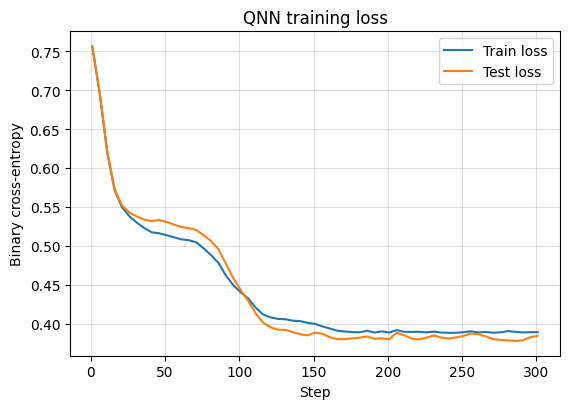

Saved plotting data to qnn_decision_plot_data.xlsx


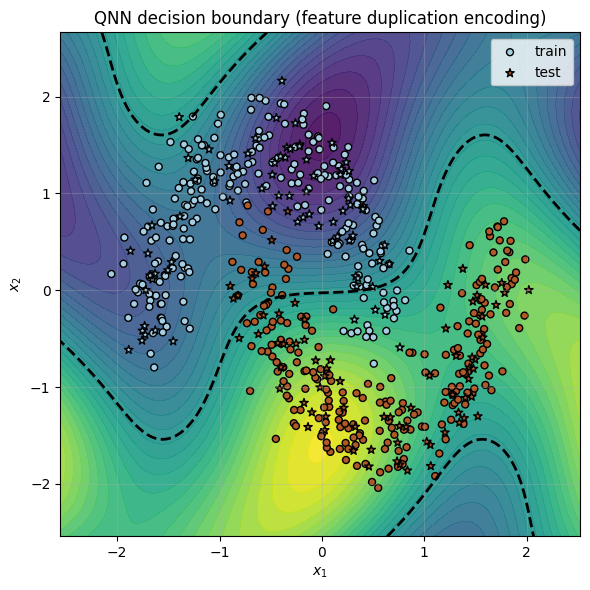

In [ ]:
# === Imports & setup ===
import numpy as np
import matplotlib.pyplot as plt
import pickle  # NEW (kept from earlier)
import pandas as pd  # NEW
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

import pennylane as qml
import pennylane.numpy as pnp

# Reproducibility
SEED = 0
np.random.seed(SEED)

# === Data: two-moons ===
N_SAMPLES = 600
NOISE = 0.15
TEST_SIZE = 0.25

X, y = make_moons(n_samples=N_SAMPLES, noise=NOISE, random_state=SEED)
X, y = shuffle(X, y, random_state=SEED)

# Standardize features (keeps rotation angles well-scaled)
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

# === Device ===
n_qubits = 4
SHOTS = None  # set e.g. SHOTS = 2048 to simulate sampling noise; None -> exact expectations
dev = qml.device("default.qubit", wires=n_qubits, shots=SHOTS)

# === Encoding: feature duplication (x1, x2, x1, x2), alphas = 1 ===
def encode_angles(x):
    x1, x2 = x
    return np.array([x1, x2, x1, x2], dtype=float)

# === Variational layer: RZ-RY-RZ per qubit + wrap-around CNOTs ===
def var_layer(theta_layer):
    """
    theta_layer shape: (4, 3) -> per-qubit (RZ, RY, RZ) angles
    Entanglers: CNOT 0->1, 1->2, 2->3, 3->0 (wrap-around)
    """
    for q in range(n_qubits):
        phi_z1, phi_y, phi_z2 = theta_layer[q]
        qml.RZ(phi_z1, wires=q)
        qml.RY(phi_y,  wires=q)
        qml.RZ(phi_z2, wires=q)

    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 2])
    qml.CNOT(wires=[2, 3])
    qml.CNOT(wires=[3, 0])

# === QNode: return expectation <Z0> (scalar float) ===
@qml.qnode(dev, interface="autograd", diff_method="parameter-shift")
def qnn_expval(x, thetas):
    """
    x: 2D input (x1, x2)
    thetas: shape (2, 4, 3) for two variational layers
    Returns: <Z on wire 0> in [-1, 1]
    """
    angles = encode_angles(x)
    for q in range(n_qubits):
        qml.RY(angles[q], wires=q)

    var_layer(thetas[0])
    var_layer(thetas[1])

    return qml.expval(qml.PauliZ(0))

# Convert expectation to probability outside the QNode
def qnn_prob(x, thetas):
    # p = (1 - <Z0>) / 2
    return (1.0 - qnn_expval(x, thetas)) / 2.0

# === Loss: Binary cross-entropy ===
def bce_loss(thetas, Xb, yb, eps=1e-8):
    probs = pnp.array([qnn_prob(x, thetas) for x in Xb])
    probs = pnp.clip(probs, eps, 1.0 - eps)  # avoid log(0)
    yb = pnp.array(yb)
    return -pnp.mean(yb * pnp.log(probs) + (1 - yb) * pnp.log(1 - probs))

def accuracy(thetas, Xd, yd, thresh=0.5):
    probs = pnp.array([qnn_prob(x, thetas) for x in Xd])
    preds = (probs >= thresh).astype(int)
    return (preds == yd).mean()

# === Training hyperparameters ===
STEPS = 300
BATCH_SIZE = 64
LR = 0.03

# Initialize trainable parameters: (layers=2, qubits=4, angles=3)
thetas = pnp.array(0.1 * np.random.randn(2, n_qubits, 3), requires_grad=True)
opt = qml.AdamOptimizer(stepsize=LR)

train_losses, test_losses = [], []

for step in range(1, STEPS + 1):
    # Mini-batch
    idx = np.random.choice(len(X_train), size=BATCH_SIZE, replace=False)
    Xb, yb = X_train[idx], y_train[idx]

    # One optimizer step (parameter-shift gradients under the hood)
    thetas = opt.step(lambda th: bce_loss(th, Xb, yb), thetas)

    # Track metrics periodically
    if step % 5 == 0 or step == 1:
        tr_loss = float(bce_loss(thetas, X_train, y_train))
        te_loss = float(bce_loss(thetas, X_test, y_test))
        train_losses.append(tr_loss)
        test_losses.append(te_loss)

        tr_acc = float(accuracy(thetas, X_train, y_train))
        te_acc = float(accuracy(thetas, X_test, y_test))
        print(f"Step {step:04d} | Train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
              f"Test loss {te_loss:.4f} acc {te_acc:.3f}")

# === Save training data for later use (pickle) ===
results = {
    "train_losses": train_losses,
    "test_losses": test_losses,
    "thetas": np.array(thetas)  # final parameters
}
with open("qnn_training_results.pkl", "wb") as f:
    pickle.dump(results, f)

# === Save training and test losses to Excel ===
df_losses = pd.DataFrame({
    "step": np.arange(len(train_losses)) * 5 + 1,
    "train_loss": train_losses,
    "test_loss": test_losses
})
df_losses.to_excel("qnn_losses.xlsx", index=False)
print("Saved training/test losses to qnn_losses.xlsx")

# === Plot: training curves ===
plt.figure(figsize=(5.8, 4.2))
plt.plot(np.arange(len(train_losses))*5 + 1, train_losses, label="Train loss")
plt.plot(np.arange(len(test_losses))*5 + 1, test_losses, label="Test loss")
plt.xlabel("Step")
plt.ylabel("Binary cross-entropy")
plt.title("QNN training loss")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig("qnn_loss_curve.png", dpi=300, bbox_inches="tight")  # 300 dpi
plt.savefig("qnn_loss_curve.pdf", bbox_inches="tight")          # vector copy
plt.show()

# === Decision boundary ===
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 240),
                     np.linspace(y_min, y_max, 240))
grid = np.c_[xx.ravel(), yy.ravel()]

probs_grid = np.array([qnn_prob(g, thetas) for g in grid]).reshape(xx.shape)

# --- SAVE all data needed to rebuild the decision-boundary figure (to Excel) ---
with pd.ExcelWriter("qnn_decision_plot_data.xlsx") as writer:
    pd.DataFrame(
        {"x1": X_train[:, 0], "x2": X_train[:, 1], "y": y_train}
    ).to_excel(writer, sheet_name="train_points", index=False)

    pd.DataFrame(
        {"x1": X_test[:, 0], "x2": X_test[:, 1], "y": y_test}
    ).to_excel(writer, sheet_name="test_points", index=False)

    pd.DataFrame(
        {"xx": xx.ravel(), "yy": yy.ravel(), "p": probs_grid.ravel()}
    ).to_excel(writer, sheet_name="decision_grid", index=False)

print("Saved plotting data to qnn_decision_plot_data.xlsx")

plt.figure(figsize=(6, 6))
cs = plt.contourf(xx, yy, probs_grid, levels=30, alpha=0.9)
plt.contour(xx, yy, probs_grid, levels=[0.5], colors="k", linestyles="--", linewidths=2)

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.Paired,
            edgecolors='k', s=25, label="train")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.Paired,
            edgecolors='k', s=40, marker="*", label="test")

plt.title("QNN decision boundary (feature duplication encoding)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("qnn_decision_boundary.png", dpi=300, bbox_inches="tight")  # 300 dpi
plt.savefig("qnn_decision_boundary.pdf", bbox_inches="tight")           # vector copy
plt.show()


Generating the traning and test data

In [ ]:
import pandas as pd

# Save train data
df_train = pd.DataFrame({
    "x1": X_train[:, 0],
    "x2": X_train[:, 1],
    "y": y_train,
    "set": "train"
})

# Save test data
df_test = pd.DataFrame({
    "x1": X_test[:, 0],
    "x2": X_test[:, 1],
    "y": y_test,
    "set": "test"
})

# Combine
df_all = pd.concat([df_train, df_test], ignore_index=True)
df_all.to_excel("qnn_decision_plot_data.xlsx", index=False)
print("Saved train/test data with labels to qnn_decision_plot_data.xlsx")


Saved train/test data with labels to qnn_decision_plot_data.xlsx


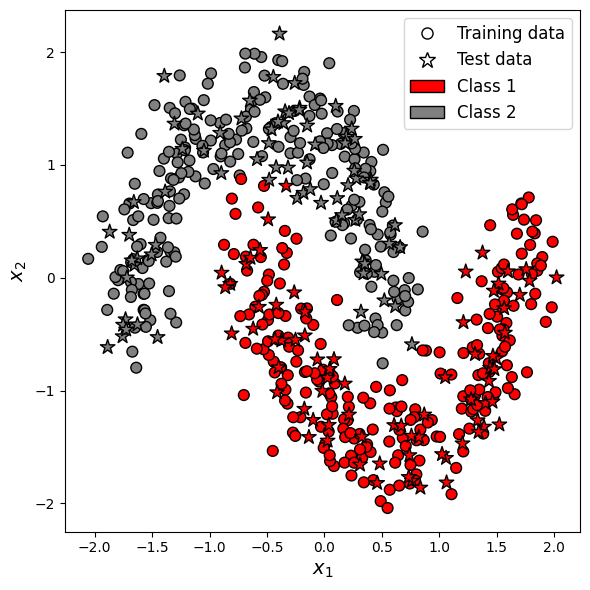

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Load Excel with "set" column
df = pd.read_excel("qnn_decision_plot_data.xlsx")

# Split into train and test
df_train = df[df["set"] == "train"]
df_test = df[df["set"] == "test"]

# Plot
plt.figure(figsize=(6, 6))

# Colors: red for class 1, gray for class 0
colors = {0: "gray", 1: "red"}

# Training points: circles
plt.scatter(
    df_train["x1"], df_train["x2"],
    c=df_train["y"].map(colors),
    edgecolors="k", s=60, marker="o"
)

# Test points: stars
plt.scatter(
    df_test["x1"], df_test["x2"],
    c=df_test["y"].map(colors),
    edgecolors="k", s=120, marker="*"
)

# Labels and aesthetics
plt.xlabel("$x_1$", fontsize=14)
plt.ylabel("$x_2$", fontsize=14)

# Custom legend: shape for split, rectangle for class
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="w",
           markeredgecolor="k", label="Training data", markersize=8),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="w",
           markeredgecolor="k", label="Test data", markersize=12),
    Patch(facecolor="red", edgecolor="k", label="Class 1"),
    Patch(facecolor="gray", edgecolor="k", label="Class 2"),
]

plt.legend(handles=legend_elements, fontsize=12, loc="best")

plt.tight_layout()

# Save high-quality versions
plt.savefig("two_moons_train_test.png", dpi=300, bbox_inches="tight")
#plt.savefig("two_moons_train_test.pdf", bbox_inches="tight")

plt.show()
